# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_2_GridSearchCV

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [13]:
labeled=pd.read_csv('labeled_data.csv', encoding='utf-8')
result_df=pd.read_csv('04_1_Imbalance_and_Feature_Experiments.csv')

In [18]:
# Grid Search 공통 라이브러리
from pathlib import Path
import importlib
import sys

from sklearn.model_selection import train_test_split
from sklearn import set_config

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.model_evaluation import evaluate_models
import utils.model_tuning as model_tuning

# 노트북 실행 중 model_tuning.py가 수정된 경우에도 최신 코드를 다시 불러옴
importlib.invalidate_caches()
model_tuning = importlib.reload(model_tuning)

grid_search_bagging_smote = model_tuning.grid_search_bagging_smote
grid_search_random_forest_balanced = model_tuning.grid_search_random_forest_balanced
grid_search_random_forest_smote = model_tuning.grid_search_random_forest_smote

set_config(display='text')

## 데이터 전처리

In [19]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# CN7, RG3 / LH, RH 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','PART_NAME', 'Reason',
              'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

X_part=final_df.drop(columns='PassOrFail')
Y=final_df['PassOrFail']

# 더미변수 생성
X_part = pd.get_dummies(data = X_part, columns = ['Part'], drop_first=True)

## 1. RandomForest PART_NAME + Balanced Grid Search

- 수정된 PART_NAME 기반 Part 더미변수를 사용합니다.
- SMOTE는 적용하지 않고 RandomForest의 class_weight='balanced'를 고정합니다.
- 평가 기준은 Average Precision이며, StandardScaler는 각 Stratified K-Fold의 학습 폴드 안에서만 적용합니다.
- 54개 조합 × 5 folds = 270 fits를 수행합니다.

In [20]:
# 세 후보가 동일한 train/test 데이터를 사용하도록 한 번만 분할
x_part_train, x_part_test, y_train, y_test = train_test_split(
    X_part,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=0,
)

In [21]:
rf_balanced_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
}

rf_balanced_grid, rf_balanced_cv_results = grid_search_random_forest_balanced(
    x_part_train,
    y_train,
    param_grid=rf_balanced_param_grid,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', rf_balanced_grid.best_score_)
print('Best Parameters:', rf_balanced_grid.best_params_)
rf_balanced_cv_results.head(10)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best CV Average Precision: 0.3144736026683655
Best Parameters: {'rf__max_depth': 20, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.314474,0.086583,2.522232,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
1,1,0.314474,0.086583,2.842252,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
2,3,0.314094,0.089344,2.996777,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
3,3,0.314094,0.089344,2.344366,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
4,5,0.303333,0.081224,3.254458,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
5,6,0.299868,0.079583,2.959865,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
6,7,0.299020,0.077207,7.845715,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
7,7,0.299020,0.077207,6.280658,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
8,9,0.298987,0.077221,9.029378,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
9,9,0.298987,0.077221,10.403776,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."


RandomForest PART_NAME + Balanced GridSearch
Accuracy: 0.9760994263862333
Average Precision: 0.5321734726291888
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.28      0.67      0.39        12

    accuracy                           0.98      1046
   macro avg       0.64      0.82      0.69      1046
weighted avg       0.99      0.98      0.98      1046



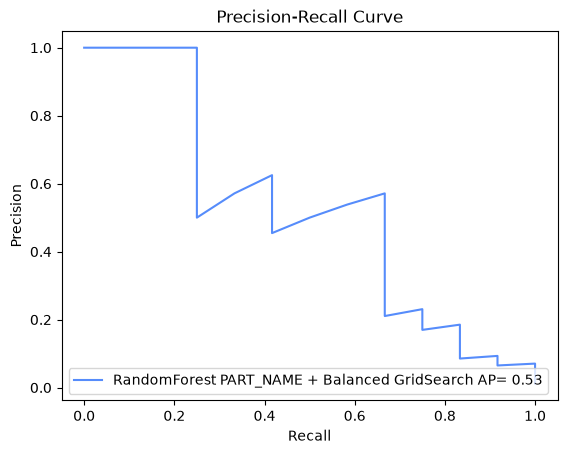

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
15,XGBoost PART_NAME+SMOTE St=0.1,0.600000,0.500000,0.545455,0.527579
16,RandomForest SMOTE St=0.1 + Balanced,0.350000,0.583333,0.437500,0.407025
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.411765,0.583333,0.482759,0.577065
18,RandomForest PART_NAME+SMOTE St=0.1+Feature,0.571429,0.333333,0.421053,0.453846
19,RandomForest PART_NAME + Balanced GridSearch,0.275862,0.666667,0.390244,0.532173


In [22]:
# Pipeline에 스케일링이 포함되어 있으므로 원본 x_part_test를 사용
rf_balanced_grid_model = {
    'RandomForest PART_NAME + Balanced GridSearch': rf_balanced_grid.best_estimator_
}
result_df = evaluate_models(
    rf_balanced_grid_model,
    x_part_test,
    y_test,
    result_df,
)
result_df.tail()

In [ ]:
rf_balanced_grid.best_params_

## 2. RandomForest PART_NAME + SMOTE St=0.1 Grid Search

- 수정된 PART_NAME 기반 Part 더미변수를 사용합니다.
- StandardScaler와 SMOTE(sampling_strategy=0.1)는 각 Stratified K-Fold의 학습 폴드 안에서만 적용합니다.
- 평가 기준은 Average Precision입니다.
- 54개 조합 × 5 folds = 270 fits를 수행합니다.

In [23]:
rf_smote_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
}

rf_smote_grid, rf_smote_cv_results = grid_search_random_forest_smote(
    x_part_train,
    y_train,
    param_grid=rf_smote_param_grid,
    sampling_strategy=0.1,
    smote_k_neighbors=3,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', rf_smote_grid.best_score_)
print('Best Parameters:', rf_smote_grid.best_params_)
rf_smote_cv_results.head(10)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best CV Average Precision: 0.25931930051914226
Best Parameters: {'rf__max_depth': 20, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 500}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.259319,0.063890,6.769175,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
1,1,0.259319,0.063890,5.680476,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
2,3,0.259312,0.063886,6.636600,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
3,3,0.259312,0.063886,4.758218,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
4,5,0.257444,0.066472,5.622423,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
5,6,0.257352,0.066430,3.076054,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."
6,7,0.256932,0.063615,3.093523,"{'rf__max_depth': 10, 'rf__min_samples_leaf': ..."
7,7,0.256932,0.063615,3.365840,"{'rf__max_depth': 10, 'rf__min_samples_leaf': ..."
8,9,0.256893,0.068147,12.072107,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
9,10,0.256869,0.068135,11.399477,"{'rf__max_depth': 20, 'rf__min_samples_leaf': ..."


RandomForest PART_NAME + SMOTE St=0.1 GridSearch
Accuracy: 0.9933078393881453
Average Precision: 0.6494681104184389
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.78      0.58      0.67        12

    accuracy                           0.99      1046
   macro avg       0.89      0.79      0.83      1046
weighted avg       0.99      0.99      0.99      1046



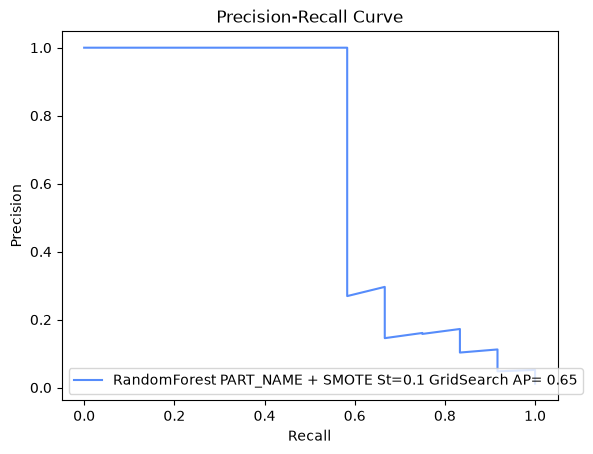

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
16,RandomForest SMOTE St=0.1 + Balanced,0.350000,0.583333,0.437500,0.407025
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.411765,0.583333,0.482759,0.577065
18,RandomForest PART_NAME+SMOTE St=0.1+Feature,0.571429,0.333333,0.421053,0.453846
19,RandomForest PART_NAME + Balanced GridSearch,0.275862,0.666667,0.390244,0.532173
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.777778,0.583333,0.666667,0.649468


In [24]:
# Pipeline에 스케일링과 SMOTE가 포함되어 있으므로 원본 x_part_test를 사용
rf_smote_grid_model = {
    'RandomForest PART_NAME + SMOTE St=0.1 GridSearch': rf_smote_grid.best_estimator_
}
result_df = evaluate_models(
    rf_smote_grid_model,
    x_part_test,
    y_test,
    result_df,
)
result_df.tail()

In [ ]:
rf_smote_grid.best_params_

## 3. Bagging PART_NAME + SMOTE St=0.1 Grid Search

- 수정된 PART_NAME 기반 Part 더미변수를 사용합니다.
- StandardScaler와 SMOTE(sampling_strategy=0.1)는 각 Stratified K-Fold의 학습 폴드 안에서만 적용합니다.
- 평가 기준은 Average Precision입니다.
- 27개 조합 × 5 folds = 135 fits를 수행합니다.

In [25]:
bagging_smote_param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0],
}

bagging_smote_grid, bagging_smote_cv_results = grid_search_bagging_smote(
    x_part_train,
    y_train,
    param_grid=bagging_smote_param_grid,
    sampling_strategy=0.1,
    smote_k_neighbors=3,
    n_splits=5,
    scoring='average_precision',
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

print('Best CV Average Precision:', bagging_smote_grid.best_score_)
print('Best Parameters:', bagging_smote_grid.best_params_)
bagging_smote_cv_results.head(10)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best CV Average Precision: 0.25770412602168163
Best Parameters: {'bagging__max_features': 0.5, 'bagging__max_samples': 1.0, 'bagging__n_estimators': 300}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
0,1,0.257704,0.081357,7.291180,"{'bagging__max_features': 0.5, 'bagging__max_s..."
1,2,0.253622,0.079896,12.219222,"{'bagging__max_features': 0.5, 'bagging__max_s..."
2,3,0.252303,0.078427,5.042772,"{'bagging__max_features': 0.5, 'bagging__max_s..."
3,4,0.252021,0.070479,7.274138,"{'bagging__max_features': 0.5, 'bagging__max_s..."
4,5,0.251879,0.073574,15.801426,"{'bagging__max_features': 0.5, 'bagging__max_s..."
5,6,0.250887,0.072884,3.986734,"{'bagging__max_features': 0.5, 'bagging__max_s..."
6,7,0.249481,0.074177,10.228463,"{'bagging__max_features': 0.5, 'bagging__max_s..."
7,8,0.248705,0.075619,20.186262,"{'bagging__max_features': 0.5, 'bagging__max_s..."
8,9,0.245866,0.075330,20.848574,"{'bagging__max_features': 0.5, 'bagging__max_s..."
9,10,0.242780,0.068909,10.707628,"{'bagging__max_features': 0.75, 'bagging__max_..."


Bagging PART_NAME + SMOTE St=0.1 GridSearch
Accuracy: 0.9894837476099426
Average Precision: 0.6228275451226851
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.54      0.58      0.56        12

    accuracy                           0.99      1046
   macro avg       0.77      0.79      0.78      1046
weighted avg       0.99      0.99      0.99      1046



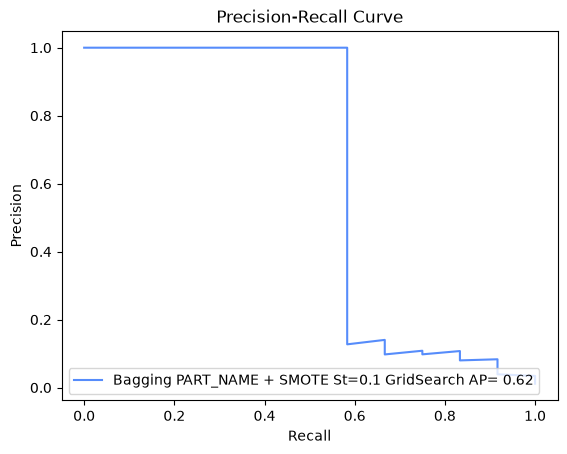

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.411765,0.583333,0.482759,0.577065
18,RandomForest PART_NAME+SMOTE St=0.1+Feature,0.571429,0.333333,0.421053,0.453846
19,RandomForest PART_NAME + Balanced GridSearch,0.275862,0.666667,0.390244,0.532173
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.777778,0.583333,0.666667,0.649468
21,Bagging PART_NAME + SMOTE St=0.1 GridSearch,0.538462,0.583333,0.560000,0.622828


In [26]:
# Pipeline에 스케일링과 SMOTE가 포함되어 있으므로 원본 x_part_test를 사용
bagging_smote_grid_model = {
    'Bagging PART_NAME + SMOTE St=0.1 GridSearch': bagging_smote_grid.best_estimator_
}
result_df = evaluate_models(
    bagging_smote_grid_model,
    x_part_test,
    y_test,
    result_df,
)
result_df.tail()

In [ ]:
bagging_smote_grid.best_params_

## Grid Search 결과 비교

In [27]:
grid_search_model_names = [
    'RandomForest PART_NAME + Balanced GridSearch',
    'RandomForest PART_NAME + SMOTE St=0.1 GridSearch',
    'Bagging PART_NAME + SMOTE St=0.1 GridSearch',
]

result_df[result_df['Model'].isin(grid_search_model_names)].sort_values(
    ['Average Precision', 'Defect Recall', 'Defect F1 Score'],
    ascending=False,
)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
20,RandomForest PART_NAME + SMOTE St=0.1 GridSearch,0.777778,0.583333,0.666667,0.649468
21,Bagging PART_NAME + SMOTE St=0.1 GridSearch,0.538462,0.583333,0.560000,0.622828
19,RandomForest PART_NAME + Balanced GridSearch,0.275862,0.666667,0.390244,0.532173
